In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
df=pd.read_csv(r'D:\project\housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [2]:
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.shape

(20640, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df['total_bedrooms'].fillna(df['total_bedrooms'].median(),inplace=True)
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
x= df[['longitude',
        'latitude',
        'housing_median_age',
        'total_rooms',
        'total_bedrooms',
        'population',
        'households',
        'median_income']]
y=df['median_house_value']

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y , test_size=0.2,random_state=42)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([ 63736.59133839, 154344.5943191 , 253073.19428742, ...,
       439178.19697502, 130408.85287046, 175272.25192552], shape=(4128,))

In [13]:
new_house = [[
    -122.23,   # longitude
    37.88,     # latitude
    41,        # housing_median_age
    880,       # total_rooms
    129,       # total_bedrooms
    322,       # population
    126,       # households
    8.3252     # median_income
]]

new_house = scaler.transform(new_house)

LR_1 = model.predict(new_house)

print(LR_1)

[411946.61039217]


In [14]:
from sklearn.metrics import r2_score

S_LR = r2_score(y_test, y_pred)

print("R2 Score :", S_LR)

R2 Score : 0.6138664756435176


In [15]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
regression_DT = DecisionTreeRegressor(random_state=42)
regression_DT.fit(x_train, y_train)
y_pred = regression_DT.predict(x_test)
S_DT = r2_score(y_test, y_pred)


In [16]:
new_house = [[
    -122.23,
    37.88,
    41,
    880,
    129,
    322,
    126,
    8.3252
]]

new_house = scaler.transform(new_house)

DT_P1 = regression_DT.predict(new_house)

print(DT_P1)
print("R2 Score :", S_DT)

[500001.]
R2 Score : 0.6274542720618482


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
regression_RF = RandomForestRegressor(random_state=42)
regression_RF.fit(x_train, y_train)
y_pred = regression_RF.predict(x_test)
S_RF = r2_score(y_test, y_pred)


In [18]:
new_house = [[
    -122.23,
    37.88,
    41,
    880,
    129,
    322,
    126,
    8.3252
]]

new_house = scaler.transform(new_house)

RF_P1 = regression_RF.predict(new_house)

print(RF_P1)
print("R2 Score :", S_RF)

[427866.34]
R2 Score : 0.8102273824388975


In [19]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score
regression_SVR = SVR()
regression_SVR.fit(x_train, y_train)
y_pred = regression_SVR.predict(x_test)
S_SVR = r2_score(y_test, y_pred)

In [20]:
new_house = [[
    -122.23,
    37.88,
    41,
    880,
    129,
    322,
    126,
    8.3252
]]

new_house = scaler.transform(new_house)

SVR_P1 = regression_SVR.predict(new_house)

print(SVR_P1)
print("R2 Score :", S_SVR)

[180801.03249459]
R2 Score : -0.043674091139450644


In [21]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

regression_KNN = KNeighborsRegressor()
regression_KNN.fit(x_train, y_train)
y_pred = regression_KNN.predict(x_test)
S_KNN = r2_score(y_test, y_pred)


In [22]:
new_house = [[
    -122.23,
    37.88,
    41,
    880,
    129,
    322,
    126,
    8.3252
]]

new_house = scaler.transform(new_house)

KNN_P1 = regression_KNN.predict(new_house)

print(KNN_P1)

[430620.6]


In [23]:
print("R2 Score :", S_KNN)

R2 Score : 0.7045738328592949


In [24]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
regression_GBR = GradientBoostingRegressor()
regression_GBR.fit(x_train, y_train)
y_pred = regression_GBR.predict(x_test)
S_GBR = r2_score(y_test, y_pred)

In [25]:
new_house = [[
    -122.23,
    37.88,
    41,
    880,
    129,
    322,
    126,
    8.3252
]]

new_house = scaler.transform(new_house)

GBR_P1 = regression_GBR.predict(new_house)

print(GBR_P1)
print("R2 Score :", S_GBR)

[412153.23921576]
R2 Score : 0.7629419438773214


In [26]:
import pandas as pd

result = pd.DataFrame({
    'Algorithm': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Support Vector Machine Regressor',
        'K-Nearest Neighbor Regressor',
        'Gradient Boosting Regressor'
    ],

    'R2 Score': [
        S_LR,
        S_DT,
        S_RF,
        S_SVR,
        S_KNN,
        S_GBR
    ],

    'Prediction': [
        LR_1[0],
        DT_P1[0],
        RF_P1[0],
        SVR_P1[0],
        KNN_P1[0],
        GBR_P1[0]
    ]
})
result

,Algorithm,R2 Score,Prediction
0,Linear Regression,0.613866,411946.610392
1,Decision Tree Regressor,0.627454,500001.000000
2,Random Forest Regressor,0.810227,427866.340000
3,Support Vector Machine Regressor,-0.043674,180801.032495
4,K-Nearest Neighbor Regressor,0.704574,430620.600000
5,Gradient Boosting Regressor,0.762942,412153.239216


In [27]:
print(df['median_house_value'].min())
print(df['median_house_value'].max())

14999.0
500001.0


In [28]:
print(x.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')


In [29]:
print(model.coef_)

[-85503.21815336 -90698.84880311  14905.90644754 -17805.41850057
  48712.34334124 -43766.49115918  17654.50065911  77194.69946558]


In [30]:
print(model.intercept_)

207194.69373788807


In [31]:
print(new_house)

[[-1.32016306  1.04692041  0.98330419 -0.81027328 -0.9773325  -0.97135592
  -0.98170523  2.33397811]]


In [32]:
importance=pd.DataFrame({'Feature':x.columns,'Importance':regression_RF.feature_importances_})
importance=importance.sort_values(by='Importance', ascending=False)
importance

,Feature,Importance
7,median_income,0.520658
0,longitude,0.156370
1,latitude,0.146093
2,housing_median_age,0.065953
5,population,0.037923
4,total_bedrooms,0.028405
3,total_rooms,0.024630
6,households,0.019968


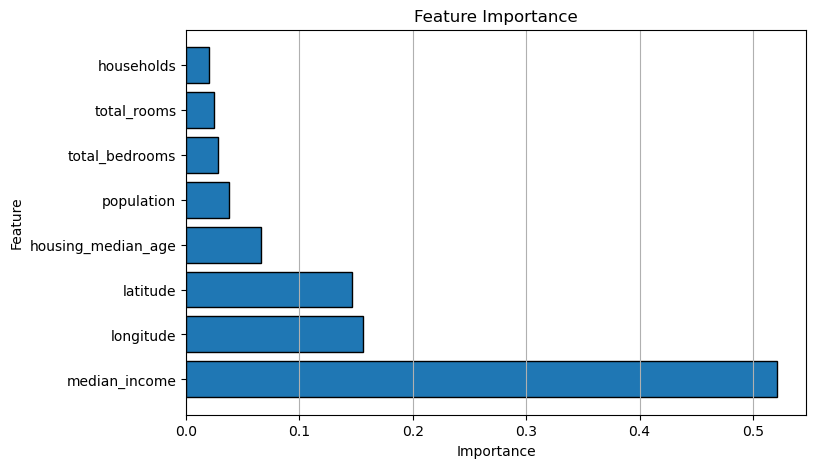

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(importance.Feature,importance.Importance,edgecolor='black')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.grid(axis='x')
plt.show()

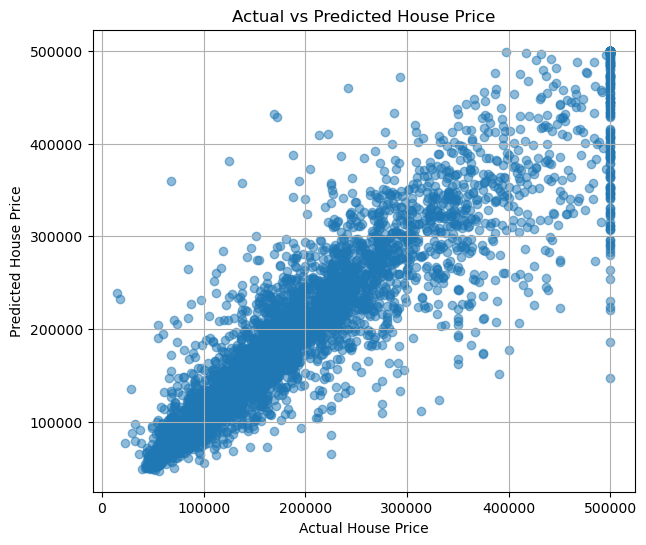

In [34]:
y_pred_rf = regression_RF.predict(x_test)

plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Price")

plt.grid(True)

plt.show()

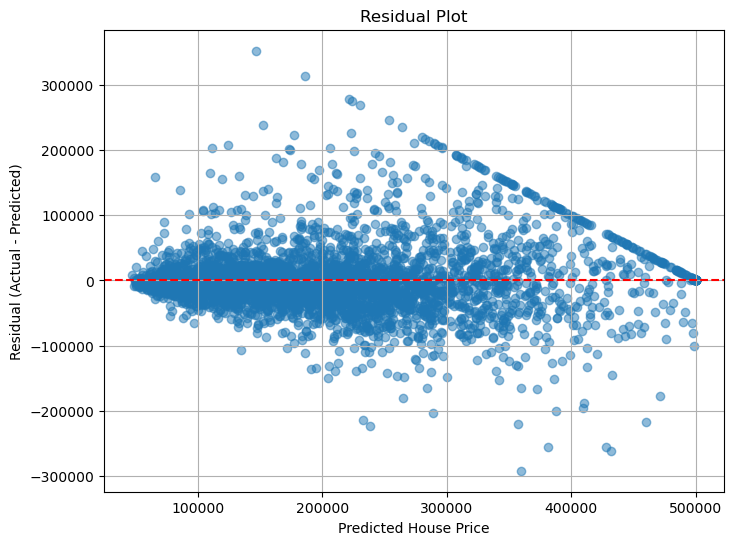

In [35]:
y_pred_rf = regression_RF.predict(x_test)

residual = y_test - y_pred_rf

plt.figure(figsize=(8,6))

plt.scatter(y_pred_rf, residual, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted House Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [36]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("RMSE :", rmse)

RMSE : 49867.79941769493


In [37]:
from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(
    regression_RF,
    x,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Fold Scores:", cv_score)
print("Average R²:", cv_score.mean())
print("Std:", cv_score.std())

Fold Scores: [0.42165377 0.62391991 0.69350803 0.57988073 0.60839415]
Average R²: 0.585471320454616
Std: 0.09004790548868943


In [38]:
from sklearn.ensemble import RandomForestRegressor

regression_RF_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

In [39]:
regression_RF_tuned.fit(x_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
y_pred_tuned = regression_RF_tuned.predict(x_test)

In [41]:
y_pred_tuned = regression_RF_tuned.predict(x_test)

In [42]:
from sklearn.metrics import r2_score

r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest R²:", r2_tuned)

Tuned Random Forest R²: 0.810905060219674


In [43]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("Tuned RMSE:", rmse_tuned)

Tuned RMSE: 49778.68086119413


In [44]:
import joblib

joblib.dump(regression_RF_tuned, "house_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [45]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [46]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [47]:
x.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

In [48]:
df_encoded =pd.get_dummies(df,columns=['ocean_proximity'], drop_first=True)


In [49]:
print(df_encoded.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')


In [50]:
x = df_encoded.drop("median_house_value", axis=1)
y = df_encoded["median_house_value"]

In [51]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [53]:
from sklearn.ensemble import RandomForestRegressor

regression_RF = RandomForestRegressor(
    random_state=42
)

regression_RF.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_pred = regression_RF.predict(x_test)

In [55]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score :", r2)

R² Score : 0.8167090228826115


In [56]:
import xgboost
print(xgboost.__version__)

3.3.0


In [57]:
!pip install xgboost

In [58]:
from xgboost import XGBRegressor

In [59]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [60]:
xgb.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [61]:
y_pred_xgb = xgb.predict(x_test)

In [62]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("R² Score :", r2)
print("RMSE :", rmse)

R² Score : 0.8346766560557105
RMSE : 46544.73055216941


In [63]:
XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [64]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

In [65]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

In [66]:
grid = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

In [67]:
grid.fit(x_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [68]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}


In [69]:
print("Best Cross Validation Score:")
print(grid.best_score_)

Best Cross Validation Score:
0.8314715869800375


In [70]:
best_model = grid.best_estimator_

y_pred = best_model.predict(x_test)

from sklearn.metrics import r2_score
import numpy as np
from sklearn.metrics import mean_squared_error

print("R² :", r2_score(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.839082891582744
RMSE : 45920.28131692321


In [71]:
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [72]:
import joblib
joblib.dump(best_model,"house_price_xgb.pkl")

['house_price_xgb.pkl']

In [73]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [74]:
import joblib

joblib.dump(best_model, "house_price_xgboost.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [75]:
# Feature Engineering

df["rooms_per_household"] = df["total_rooms"] / df["households"]

df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

df["population_per_household"] = df["population"] / df["households"]

In [76]:
df_encoded = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)

In [77]:
x = df_encoded.drop("median_house_value", axis=1)

y = df_encoded["median_house_value"]

In [78]:
print(x.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [79]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [81]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Base Model
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

# Hyperparameter Grid
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Train Model
grid_search.fit(x_train, y_train)

# Best Model
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}


In [82]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

prediction = best_model.predict(x_test)

print("R² :", r2_score(y_test, prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))

R² : 0.8425066080105681
RMSE : 45429.14866873085


In [83]:
import joblib

joblib.dump(best_model, "house_price_xgboost.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model and Scaler Saved Successfully")

✅ Model and Scaler Saved Successfully


In [84]:
print(x.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
